# Modelo de Identificação de Fraudes

- Informações da base:
    - 'Time' (tempo): contém os segundos decorridos entre cada transação e a primeira transação no conjunto de dados. 
    - 'Amount' (valor): é o valor da transação 
    - 'Class' (classe): é a variável de resposta e assume valor 1 em caso de fraude e 0 caso contrário.
    - "Infelizmente, devido a questões de confidencialidade, não podemos fornecer os recursos originais e mais informações básicas sobre os dados. Características V1, V2, … V28 são os principais componentes obtidos com PCA"

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import datetime as dt

from scipy.stats import kstest, normaltest, anderson

from sklearn.preprocessing import PowerTransformer, MinMaxScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree, metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.under_sampling import RandomUnderSampler, ClusterCentroids, NearMiss 
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.combine import SMOTEENN

from sklearn.metrics import (
    confusion_matrix, 
    accuracy_score, 
    precision_score, 
    recall_score,
    precision_recall_curve,
)

import warnings
from src.config import DADOS_MASTERCARD

warnings.filterwarnings('ignore')
sns.set_theme(palette="bright")

In [5]:
# Importando a base

transacoes = pd.read_csv(DADOS_MASTERCARD)

In [4]:
# Verificar se todos os valores podem ser convertidos para inteiro (sem valores decimais)

if (transacoes['Time'] == transacoes['Time'].astype(int)).all():
    
    # Se todos os valores são inteiros, realizar a conversão
    
    transacoes['Time'] = transacoes['Time'].astype(int)
   
else:
    print("Nem todos os valores na coluna 'Time' podem ser convertidos para inteiro.")

In [5]:
transacoes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  int32  
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
# Visualizando a estatística descritiva da base

transacoes.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### Plotando boxplots para observar outliers.

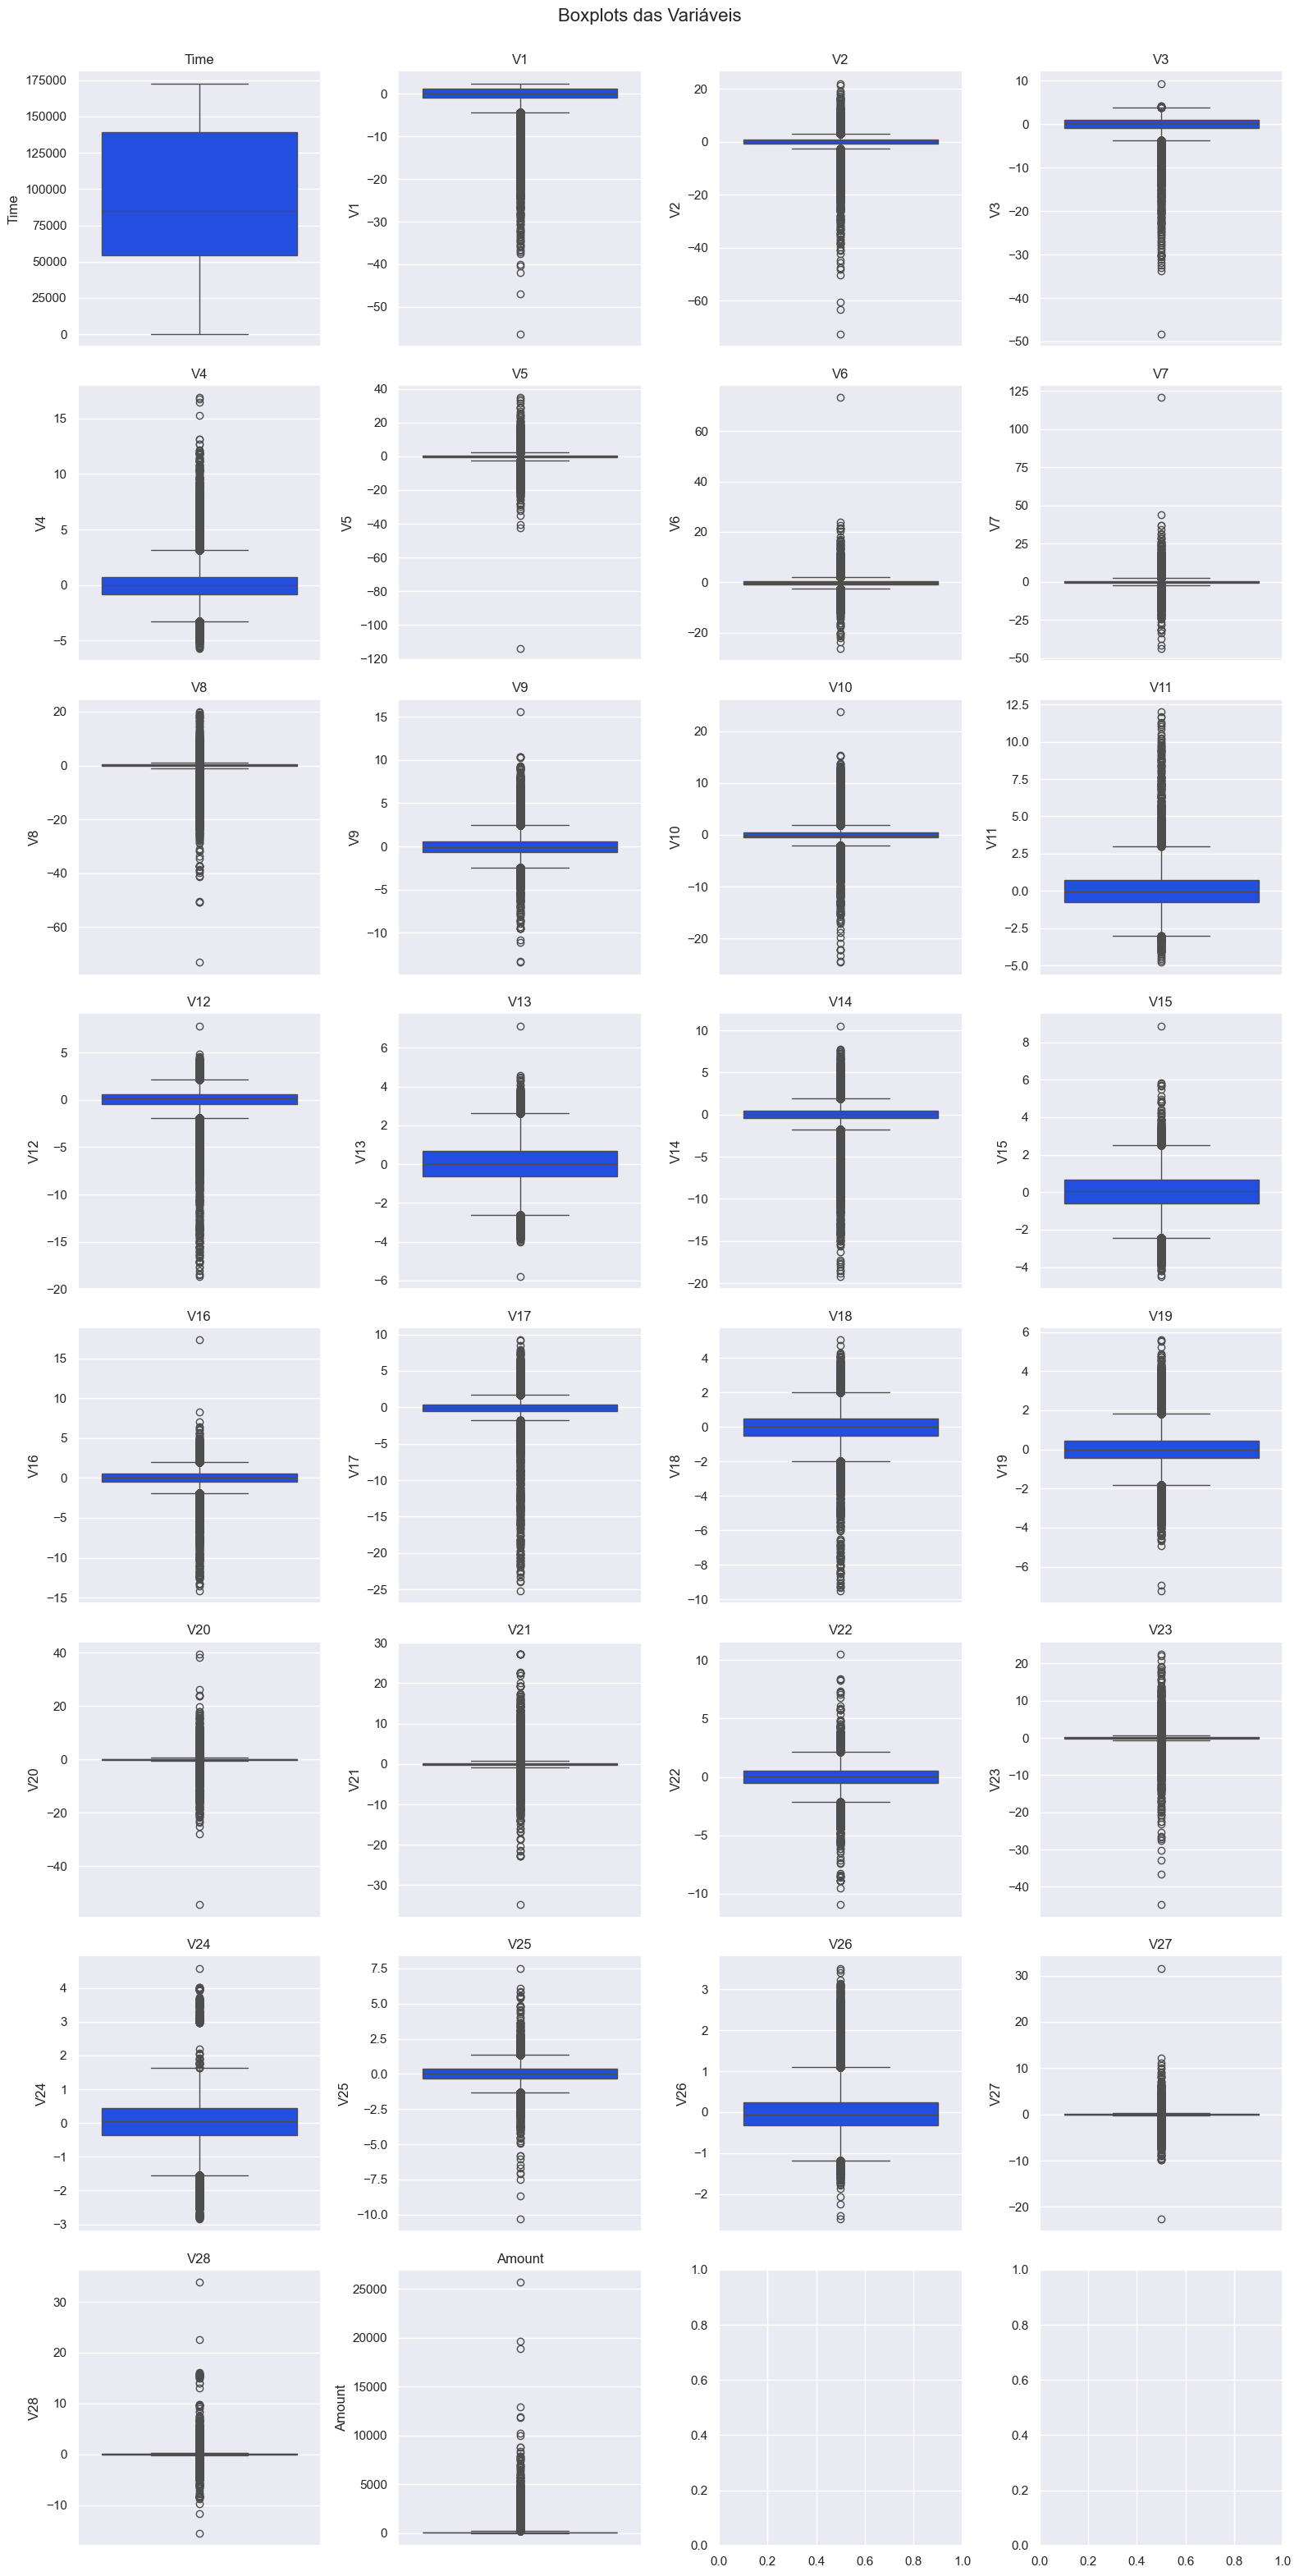

In [8]:
# Removendo 'Time' e 'Class', pois normalmente não são usados em análise de variáveis contínuas

features = [col for col in transacoes.columns if col not in ['Class']]

# Configuração do layout

fig, axes = plt.subplots(nrows=8, ncols=4, figsize=(16, 32))
fig.suptitle('Boxplots das Variáveis', fontsize=16)

# Converter axes para um array 1D para iteração

axes = axes.flatten()

# Criar os boxplots

for i, feature in enumerate(features):
    sns.boxplot(y=transacoes[feature], ax=axes[i])
    axes[i].set_title(feature)
    axes[i].set_xlabel('')

# Ajustar espaçamento

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### Testes de Hipóteses

**Para termos certeza se aplicaremos no pré-processamento Padronização ou Normalização. Precisamos saber se as amostras possuem uma distribuição normal ou próximo a uma distribuição normal.**

In [10]:
# Lista de colunas numéricas (excluindo "Time" e "Class", que é o target)
colunas_numericas = [col for col in transacoes.columns if col not in ['Time', 'Class']]

# Dicionário para armazenar os resultados
resultados = {}

for col in colunas_numericas:
    dados = transacoes[col].dropna()  # Remover valores NaN
    
    # Normalizar os dados (média 0, desvio padrão 1) para o teste KS
    dados_norm = (dados - dados.mean()) / dados.std()
    
    # Teste KS
    ks_p = kstest(dados_norm, 'norm')[1]  # P-valor
    
    # Teste de D’Agostino e Pearson
    dagostino_p = normaltest(dados)[1]
    
    # Teste de Anderson-Darling
    anderson_stat = anderson(dados, 'norm').statistic
    
    # Consideramos que p > 0.05 sugere normalidade (não rejeitamos H0)
    normal = (ks_p > 0.05) and (dagostino_p > 0.05)
    
    # Armazena os resultados
    resultados[col] = {
        'KS_p': ks_p,
        'D’Agostino_p': dagostino_p,
        'Anderson_Stat': anderson_stat,
        'Normal': normal
    }

# Transformar em DataFrame para melhor visualização
df_resultados = pd.DataFrame(resultados).T

# Exibir as colunas que têm maior probabilidade de serem normais
df_resultados.sort_values(by="Anderson_Stat")

,KS_p,D’Agostino_p,Anderson_Stat,Normal
V13,0.0,0.0,51.548222,False
V15,0.0,0.0,374.85921,False
V22,0.0,0.0,381.827528,False
V11,0.0,0.0,398.306358,False
V18,0.0,0.0,587.333585,False
V25,0.0,0.0,654.870496,False
V19,0.0,0.0,1083.356488,False
V9,0.0,0.0,1129.337093,False
V16,0.0,0.0,1502.000508,False
V4,0.0,0.0,1558.197957,False


### Pré-processamento: 

**- Utilizaremos o PowerTransformer devido ao grande número de outliers, exceto em 'Time'.**<br>
**- Em 'Time' utilizaremos o MinMaxScaler.**

In [12]:
# Selecionar as colunas para normalização (exceto 'Class' e 'Time')
colunas_para_normalizar = [col for col in transacoes.columns if col not in ['Class', 'Time']]

# Inicializar o PowerTransformer (Yeo-Johnson)
pt = PowerTransformer(method='yeo-johnson')

# Inicializar o MinMaxScaler para a coluna 'Time'
scaler = MinMaxScaler()

# Criar uma cópia do DataFrame para preservar o original
transacoes_normalizadas = transacoes.copy()

# Normalizar as colunas com PowerTransformer (exceto 'Class' e 'Time')
transacoes_normalizadas[colunas_para_normalizar] = pt.fit_transform(transacoes[colunas_para_normalizar])

# Normalizar a coluna 'Time' com MinMaxScaler
transacoes_normalizadas[['Time']] = scaler.fit_transform(transacoes[['Time']])

In [13]:
# Exibir as primeiras linhas do DataFrame normalizado

transacoes_normalizadas.head(2)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-0.904815,-0.131503,2.176074,0.983588,-0.256110,0.459227,0.193516,0.020305,0.380443,...,-0.00767,0.366644,-0.189647,0.015102,0.211929,-0.323884,0.323027,-0.053332,1.119013,0
1,0.0,0.626390,0.093067,-0.035062,0.387928,0.031947,0.045846,-0.063874,0.006711,-0.184488,...,-0.29876,-0.884170,0.153342,-0.637483,0.288440,0.353130,-0.035793,0.057491,-1.128464,0


In [14]:
# Visualizando a estatística descritiva da base normalizada

transacoes_normalizadas.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000
mean,0.548717,-3.512709e-17,-2.395029e-18,-7.344756e-17,1.836189e-17,4.470721e-17,1.516852e-17,7.983430e-19,8.781773e-18,-1.970909e-18,...,2.694408e-18,-6.785916e-18,1.017887e-17,-2.963848e-17,8.382602e-17,2.462389e-17,-3.118527e-19,2.819149e-18,-3.991715e-18,0.001727
std,0.274828,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,...,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,0.041527
min,0.000000,-8.474209e+00,-2.371418e+01,-1.301749e+01,-5.019738e+00,-7.329386e+01,-4.255940e+01,-3.515221e+01,-2.807450e+01,-1.637021e+01,...,-6.327021e+01,-1.331922e+01,-5.864168e+01,-3.535587e+00,-1.462784e+01,-8.024445e+00,-4.459955e+01,-6.138567e+01,-2.013010e+00,0.000000
25%,0.313681,-7.229843e-01,-4.535393e-01,-7.123539e-01,-5.694044e-01,-5.092615e-01,-5.567794e-01,-4.479996e-01,-2.749846e-01,-5.609001e-01,...,-3.024685e-01,-7.557923e-01,-2.720975e-01,-6.594300e-01,-6.344037e-01,-6.498315e-01,-1.899149e-01,-1.525768e-01,-7.509351e-01,0.000000
50%,0.490138,-2.489598e-01,-4.167429e-02,-2.512616e-02,6.318167e-02,-5.108320e-02,-1.140057e-01,3.224257e-02,-5.537799e-02,6.934394e-03,...,-2.316512e-02,-1.097852e-02,-2.948935e-02,-2.967327e-02,-6.929268e-03,-1.758425e-02,-9.972324e-03,4.673230e-02,2.710132e-02,0.000000
75%,0.806290,7.357771e-01,4.754402e-01,6.738369e-01,5.828420e-01,4.362457e-01,4.134314e-01,4.609974e-01,2.558749e-01,5.825380e-01,...,2.740504e-01,7.213460e-01,2.290998e-01,7.058649e-01,6.583519e-01,5.778472e-01,2.154882e-01,2.531752e-01,7.483193e-01,0.000000
max,1.000000,1.868337e+00,2.342550e+01,1.143255e+01,8.543672e+00,2.750233e+01,2.306058e+01,9.768921e+01,3.740342e+01,1.073049e+01,...,2.963924e+01,1.641212e+01,4.332679e+01,1.238450e+01,1.909465e+01,4.937290e+00,1.038741e+02,7.561007e+01,3.674446e+00,1.000000


### Criando um modelo de aprendizado de máquinas para identificar fraude

**Podemos ajustar as colunas Time e Amount para que elas fiquem entre 0 e 1**

In [17]:
# Separando X e y

X = transacoes_normalizadas.drop('Class',axis=1)
y = transacoes_normalizadas.Class

### Separando em treino e teste

In [19]:
# Separando em treino e teste

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0,stratify=y)

### Realizando o random undersampling

In [21]:
# Definindo o RandomUnderSampler

rus = RandomUnderSampler(random_state=42)

In [22]:
# Definindo a nova amostra

X_resRU, y_resRU = rus.fit_resample(X_train, y_train)

### Nos passos anteriores, tivemos como os melhores hiperparâmetros:
- **<font color='blue'>Regressão Logística:**
    - {'C': 0.001, 'solver': 'liblinear'}\
- **<font color='blue'>SVC:**
    - {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}
- **<font color='blue'>Random Forest:**
    - {'criterion': 'gini', 'max_depth': 9, 'n_estimators': 30}

In [24]:
# Utilizando a Regressão Logística

clf_RL = LogisticRegression(random_state=0,
                            C=0.001,
                            solver='liblinear').fit(X_resRU, y_resRU)

y_pred_RL = clf_RL.predict(X_test)

confusion_matrix(y_test,y_pred_RL)

array([[85420,  8405],
       [   13,   149]], dtype=int64)

In [25]:
# Avaliando o modelo

recall_score(y_test,y_pred_RL)

0.9197530864197531

In [26]:
# Utilizando o SVC

clf_SVC = SVC(random_state=0,
              probability=True,
              C=100,
              gamma='auto',
              kernel='rbf').fit(X_resRU, y_resRU)

y_pred_SVC = clf_SVC.predict(X_test)

confusion_matrix(y_test,y_pred_SVC)

array([[85791,  8034],
       [   14,   148]], dtype=int64)

In [27]:
# Avaliando o modelo

recall_score(y_test,y_pred_SVC)

0.9135802469135802

In [28]:
# Utilizando o Random Forest

clf_RF = RandomForestClassifier(max_depth=9, 
                                random_state=0,
                                criterion='gini',
                                n_estimators=30).fit(X_resRU, y_resRU)

y_pred_RF = clf_RF.predict(X_test)

confusion_matrix(y_test,y_pred_RF)

array([[91462,  2363],
       [   19,   143]], dtype=int64)

In [29]:
# Avaliando o modelo

recall_score(y_test,y_pred_RF)

0.8827160493827161

### Podemos observar que o melhor resultado foi obtido com a utilização da Regressão Logística.

### Para melhorar, podemos adicionar novos parâmetros.

**E novamente utilizar o GridSearchCV**

In [33]:
# Adicionando novos parâmetros

parametros = {
    'C': [0.001,0.01,0.1,1,10,100,1000],
    'solver': ['newton-cg','lbfgs','liblinear','sag','saga']
}

In [34]:
# Selecionando a Regressão Logística

LogReg = LogisticRegression(random_state=0)

In [35]:
# Criando o classificador

clf_RL2 = GridSearchCV(LogReg, parametros,
                       scoring='recall'
                      ).fit(X_resRU,y_resRU)

In [36]:
clf_RL2.best_params_

{'C': 0.001, 'solver': 'liblinear'}

In [37]:
# E avaliando o modelo

y_pred_RL2 = clf_RL2.predict(X_test)

confusion_matrix(y_test,y_pred_RL2)

array([[85420,  8405],
       [   13,   149]], dtype=int64)

In [38]:
# Utilizando a Acurácia

accuracy_score(y_test, y_pred_RL2)

0.9104344217817357

In [39]:
# Utilizando a Precisão

precision_score(y_test, y_pred_RL2, average='weighted')

0.9981544773261866

In [40]:
# Recall com todos os parâmetros

recall_score(y_test,y_pred_RL2)

0.9197530864197531